# Linear-vs-vol grid — winner autopsy

The best league row gets the treatment the kink-fade lesson demands:
neighborhood stability (a real edge is not an island), config-matched
placebos (the same coordinates under a Gaussian tree and a wrong
calendar), and confound checks (FOMC proximity, IMM-roll windows — 22 of
33 SR3 rolls ARE decision dates).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from SDRUtils.analytics.fomc import load_fomc_schedule  # noqa: E402
from linvol_grid_common import pick_winner  # noqa: E402

DATA = Path("../data/linvol_grid")
league = pd.read_parquet(DATA / "league.parquet")
real = league[league["family"].isin(["A", "B", "C", "E"])]
live = real[real["n_trades"] > 0]
w = pick_winner(live)
print("WINNER:", w[["family", "boundary", "dte", "gated", "thr", "direction",
                    "n_trades", "total_gross_bp", "net_1x_bp", "net_2x_bp",
                    "t_stat"]].to_dict())

WINNER: {'family': 'B', 'boundary': 'modal_fly', 'dte': '135-400', 'gated': False, 'thr': 0.1, 'direction': 'long_disp', 'n_trades': 10, 'total_gross_bp': 7.750000000000002, 'net_1x_bp': -2.2499999999999982, 'net_2x_bp': -12.249999999999998, 't_stat': -0.24355973454502453}


## The trade log and the equity curve

symbol      entry       exit  gross_bp  net_1x_bp exit_reason
SFRH25 2024-07-05 2025-03-11      4.00       3.00   dte_floor
SFRM25 2024-08-20 2024-10-03     -0.75      -1.75   dte_floor
SFRU25 2025-03-06 2025-05-01     -0.50      -1.50   dte_floor
SFRM25 2025-02-12 2025-06-10      3.00       2.00   dte_floor
SFRZ25 2025-03-24 2025-12-09     -0.25      -1.25   dte_floor
SFRH26 2025-06-24 2026-01-05     -5.75      -6.75   dte_floor
SFRM26 2026-01-16 2026-06-09      3.50       2.50   dte_floor
SFRU26 2026-03-12 2026-07-28      2.75       1.75   time_stop
SFRZ26 2026-06-17 2026-07-28      2.00       1.00   time_stop
SFRH27 2026-07-22 2026-07-27     -0.25      -1.25   time_stop


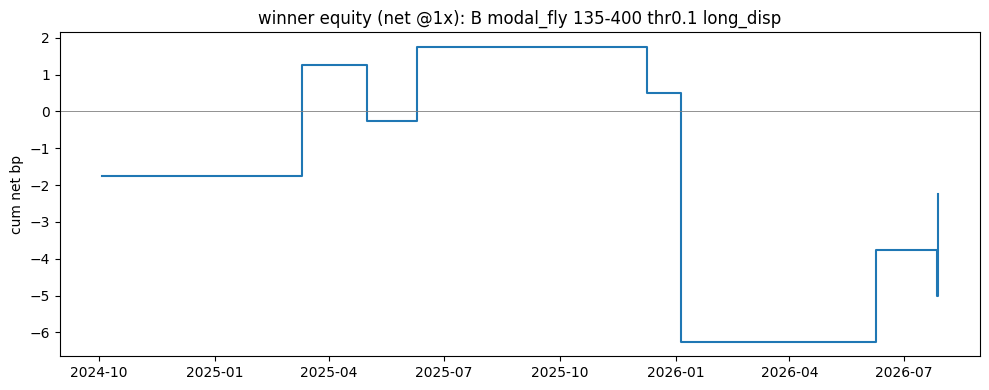

In [2]:
tl_path = DATA / f"trades_{w['family']}_best.parquet"
tl = pd.read_parquet(tl_path) if tl_path.exists() else pd.DataFrame()
if len(tl):
    tl["entry"] = pd.to_datetime(tl["entry"])
    tl["exit"] = pd.to_datetime(tl["exit"])
    print(tl.round(2).to_string(index=False))
    fig, ax = plt.subplots(figsize=(10, 4))
    eq = tl.sort_values("exit").set_index("exit")["net_1x_bp"].cumsum()
    ax.step(eq.index, eq.values, where="post")
    ax.set_title(f"winner equity (net @1x): {w['family']} {w['boundary']} "
                 f"{w['dte']} thr{w['thr']} {w['direction']}")
    ax.set_ylabel("cum net bp")
    ax.axhline(0, color="gray", lw=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("no persisted trade log for the winner family")

## Neighborhood — a real edge survives one grid step in every direction

In [3]:
nb = real[(real["family"] == w["family"])
          & (real["boundary"] == w["boundary"])
          & (real["direction"] == w["direction"])]
print(nb[["dte", "gated", "thr", "n_trades", "net_1x_bp", "net_2x_bp",
          "t_stat"]].round(2).to_string(index=False))
n_pos = int((nb["net_1x_bp"] > 0).sum())
print(f"\nneighborhood: {n_pos}/{len(nb)} configs positive at 1x costs "
      f"(median {nb['net_1x_bp'].median():+.1f}bp) -> "
      + ("SUPPORTED" if n_pos > len(nb) / 2 else "ISLAND — treat the winner "
         "as selection until proven otherwise"))

    dte  gated  thr  n_trades  net_1x_bp  net_2x_bp  t_stat
  30-60  False  0.0         1       1.75       0.75     NaN
  30-60  False  0.0         1       2.00       1.00     NaN
  30-60  False  0.1         1       1.75       0.75     NaN
  30-60  False  0.1         1       2.00       1.00     NaN
  30-60  False  0.2         1       1.75       0.75     NaN
  30-60  False  0.2         1       2.00       1.00     NaN
  60-90  False  0.0         2      -2.00      -4.00   -2.00
  60-90  False  0.0         3       3.00      -0.00    0.79
  60-90  False  0.1         1      -0.50      -1.50     NaN
  60-90  False  0.1         2       4.50       2.50    9.00
  60-90  False  0.2         0       0.00       0.00     NaN
  60-90  False  0.2         1       2.00       1.00     NaN
 90-135  False  0.0         3      -2.25      -5.25   -5.20
 90-135  False  0.0         3       2.50      -0.50    0.40
 90-135  False  0.1         3      -2.25      -5.25   -5.20
 90-135  False  0.1         3       2.50

## Config-matched placebos — the mechanism test

In [4]:
key_cols = ["boundary", "dte", "gated", "thr", "direction"]
if w["family"] == "A":
    for tag, name in (("P1_gauss", "Gaussian tree (same moments, no "
                       "lattice)"), ("P2_calendar", "wrong calendar")):
        p = league[league["family"] == tag]
        m = p.merge(w[key_cols].to_frame().T, on=key_cols, how="inner")
        if len(m):
            r = m.iloc[0]
            print(f"{name}: SAME config -> n={int(r['n_trades'])}  "
                  f"net1x {r['net_1x_bp']:+.1f}bp "
                  f"(real: {w['net_1x_bp']:+.1f}bp)")
        else:
            print(f"{name}: config row not found")
    print("\nRead: lattice information should survive P1 poorly and P2 not "
          "at all; an edge that persists under both is option "
          "mean-reversion wearing a costume.")
else:
    print(f"winner family {w['family']} has no A-family placebo pair; "
          "placebo battery applies to the convergence family only.")

winner family B has no A-family placebo pair; placebo battery applies to the convergence family only.


## Confounds — where does the PnL actually live?

In [5]:
if len(tl):
    fomc = load_fomc_schedule("USD-SOFR-1D")
    decisions = pd.to_datetime(fomc["effective_date"])
    tl["days_to_decision"] = tl["entry"].apply(
        lambda d: int((decisions - d).abs().min().days))
    near = tl[tl["days_to_decision"] <= 3]
    print(f"trades entered within 3 days of an FOMC boundary: {len(near)}"
          f"/{len(tl)}  carrying {near['net_1x_bp'].sum():+.1f} of "
          f"{tl['net_1x_bp'].sum():+.1f}bp total net")
    per_sym = tl.groupby("symbol")["net_1x_bp"].agg(["count", "sum"])
    print("\nper-symbol concentration:")
    print(per_sym.round(1).to_string())
    top_share = tl["net_1x_bp"].max() / tl["net_1x_bp"].sum() \
        if tl["net_1x_bp"].sum() != 0 else np.nan
    print(f"\nlargest single trade / total net: {top_share:.0%}"
          if np.isfinite(top_share) else "")
else:
    print("no trade log — confound checks skipped")

trades entered within 3 days of an FOMC boundary: 1/10  carrying +1.0 of -2.2bp total net

per-symbol concentration:
        count  sum
symbol            
SFRH25      1  3.0
SFRH26      1 -6.8
SFRH27      1 -1.2
SFRM25      2  0.2
SFRM26      1  2.5
SFRU25      1 -1.5
SFRU26      1  1.8
SFRZ25      1 -1.2
SFRZ26      1  1.0

largest single trade / total net: -133%
